<a href="https://www.kaggle.com/code/nikita2901699/homework-nn?scriptVersionId=293037779" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [123]:
import torch  
from torchvision import datasets, transforms

In [124]:
data_dir = "/kaggle/input/fruit-recognition/train/train"

In [125]:
dataset = datasets.ImageFolder(data_dir)

In [126]:
len(dataset)

16854

In [127]:
img, label = dataset[3526]

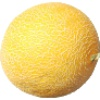

In [128]:
img 

In [129]:
dataset.classes

['Apple Braeburn',
 'Apple Granny Smith',
 'Apricot',
 'Avocado',
 'Banana',
 'Blueberry',
 'Cactus fruit',
 'Cantaloupe',
 'Cherry',
 'Clementine',
 'Corn',
 'Cucumber Ripe',
 'Grape Blue',
 'Kiwi',
 'Lemon',
 'Limes',
 'Mango',
 'Onion White',
 'Orange',
 'Papaya',
 'Passion Fruit',
 'Peach',
 'Pear',
 'Pepper Green',
 'Pepper Red',
 'Pineapple',
 'Plum',
 'Pomegranate',
 'Potato Red',
 'Raspberry',
 'Strawberry',
 'Tomato',
 'Watermelon']

In [130]:
data_train, data_test = torch.utils.data.random_split(dataset,[0.8, 0.2])

In [131]:
len(data_train)

13484

In [132]:
len(data_test)


3370

In [133]:
img, label = data_train[5000]


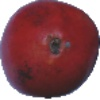

In [134]:
img

In [135]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(180, fill=255),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])


In [136]:
train_transform(img).shape

torch.Size([3, 224, 224])

In [137]:
test_transform = transforms.Compose(
    [transforms.Resize([224, 224]),
    transforms.ToTensor()
    ]
)

In [138]:
test_transform(img).shape


torch.Size([3, 224, 224])

In [139]:
from torch.utils.data import Dataset,DataLoader

class TransformDataset(Dataset):
    def __init__(self, dataset, transformer):
        super().__init__()
        self.dataset = dataset
        self.transformer = transformer

    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        img, y = self.dataset[idx]

        new_img = self.transformer(img)
        
        return new_img, y

In [140]:
train_data = TransformDataset(data_train,train_transform)


In [141]:
test_data = TransformDataset(data_test,test_transform)


In [142]:
len(test_data)


3370

In [143]:
test_data[666]

(tensor([[[1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
          [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
          [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
          ...,
          [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
          [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
          [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000]],
 
         [[0.9882, 0.9882, 0.9882,  ..., 1.0000, 1.0000, 1.0000],
          [0.9882, 0.9882, 0.9882,  ..., 1.0000, 1.0000, 1.0000],
          [0.9882, 0.9882, 0.9922,  ..., 1.0000, 1.0000, 1.0000],
          ...,
          [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
          [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
          [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000]],
 
         [[1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
          [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
          [1.0000, 1.0000, 1.0000,  ...,

In [144]:
train_loader = DataLoader(train_data, batch_size=256)


In [145]:
test_loader = DataLoader(test_data, batch_size=256)


In [146]:
for img,idx in test_loader:
     print(img.shape)
     print(idx.shape) 

torch.Size([256, 3, 224, 224])
torch.Size([256])
torch.Size([256, 3, 224, 224])
torch.Size([256])
torch.Size([256, 3, 224, 224])
torch.Size([256])
torch.Size([256, 3, 224, 224])
torch.Size([256])
torch.Size([256, 3, 224, 224])
torch.Size([256])
torch.Size([256, 3, 224, 224])
torch.Size([256])
torch.Size([256, 3, 224, 224])
torch.Size([256])
torch.Size([256, 3, 224, 224])
torch.Size([256])
torch.Size([256, 3, 224, 224])
torch.Size([256])
torch.Size([256, 3, 224, 224])
torch.Size([256])
torch.Size([256, 3, 224, 224])
torch.Size([256])
torch.Size([256, 3, 224, 224])
torch.Size([256])
torch.Size([256, 3, 224, 224])
torch.Size([256])
torch.Size([42, 3, 224, 224])
torch.Size([42])


(224, 224, 3)


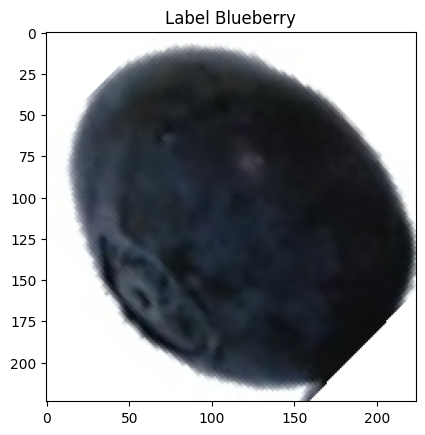

(224, 224, 3)


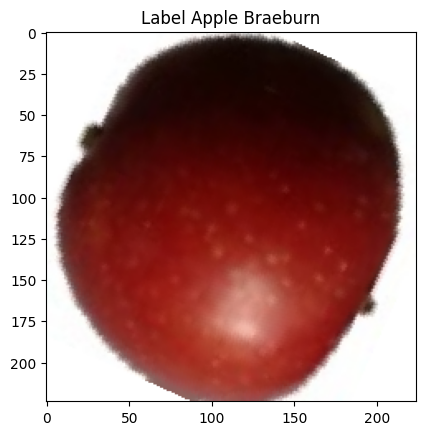

(224, 224, 3)


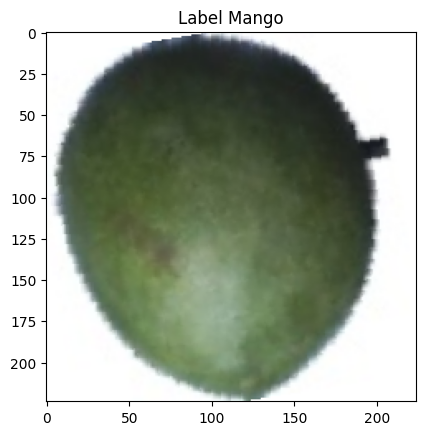

In [147]:
import matplotlib.pyplot as plt

for i in range(3):  # Show 3 images

    # Get the image data (tensor) and convert it back to a NumPy array for manipulation
    img, y = train_data[i]
    img = img.numpy()
    
    # Convert the color channels from (channels, height, width) to (height, width, channels) for pyplot
    img = img.transpose((1, 2, 0))
    print(img.shape)
    
    # Get the label name from the dataset class labels
    label = dataset0.classes[y]

    # Plot the image with a title (including label name)
    plt.imshow(img)
    plt.title(f"Label {label}")
    plt.show()

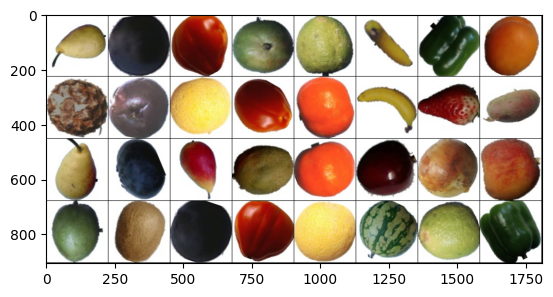

In [148]:
from torchvision.utils import make_grid

loader = torch.utils.data.DataLoader(train_data, shuffle=True, batch_size=32)

  
batch, labels = next(iter(loader))

grid = make_grid(batch).permute(1, 2, 0) # результатом є тензор

plt.imshow(grid)